In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import os

In [28]:
# Carregar os dados
df = pd.read_csv("dados\\jogadores_fifa_2024_limpo.csv")

In [29]:
# Jogador e Posição referência
id_jogador_ref = 238794
posicao_ref = "Extremo"
overall = None
potencial_ref = None
value_eur = None
wage_eur = None
age = None
club_contract_valid_until_year = None
nationality_name = None
release_clause_eur = None
player_tags = None
player_traits = None




In [30]:
ratings_goleiro = ['skill_long_passing', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance',
                   'power_shot_power', 'power_jumping', 'power_strength', 'mentality_vision', 'mentality_composure',
                   'goalkeeping_diving', 'goalkeeping_handling', 'goalkeeping_kicking', 'goalkeeping_positioning', 'goalkeeping_reflexes',
                   'goalkeeping_speed']




ratings_zagueiro = ['pace', 'passing', 'dribbling', 'defending', 'physic', 'attacking_heading_accuracy', 'attacking_short_passing', 'skill_long_passing',
                   'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_reactions', 'power_jumping', 'power_stamina',
                   'power_strength', 'mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 'mentality_vision', 'mentality_composure',
                   'defending_marking_awareness', 'defending_standing_tackle', 'defending_sliding_tackle', 'attacking_work_rate', 'defending_work_rate']




ratings_lateral = ['pace', 'passing', 'dribbling', 'defending', 'physic', 'attacking_crossing', 'attacking_short_passing', 'skill_curve', 
                   'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions',
                   'power_stamina', 'power_long_shots', 'mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 'mentality_vision',
                   'mentality_composure', 'defending_marking_awareness', 'defending_standing_tackle', 'defending_sliding_tackle',
                   'attacking_work_rate', 'defending_work_rate']




ratings_volante = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'attacking_heading_accuracy', 'attacking_short_passing',
                   'skill_dribbling', 'skill_long_passing', 'movement_acceleration', 'movement_agility', 'movement_reactions', 'movement_balance',
                   'power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots', 'mentality_aggression',
                   'mentality_interceptions', 'mentality_positioning', 'mentality_vision', 'mentality_composure', 'defending_marking_awareness',
                   'defending_standing_tackle', 'defending_sliding_tackle', 'attacking_work_rate', 'defending_work_rate']




ratings_ala = ['pace', 'shooting', 'passing',  'dribbling', 'defending', 'physic', 'attacking_crossing', 'attacking_finishing', 'attacking_short_passing', 'skill_dribbling',
            'skill_curve', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions',
            'movement_balance', 'power_shot_power', 'power_jumping', 'power_stamina', 'power_long_shots', 'mentality_aggression', 'mentality_interceptions',
            'mentality_positioning', 'mentality_vision', 'mentality_composure', 'defending_marking_awareness', 'defending_standing_tackle', 'defending_sliding_tackle',
            'attacking_work_rate', 'defending_work_rate']




ratings_meiocampo = ['pace', 'shooting', 'passing', 'dribbling', 'physic', 'attacking_finishing', 'attacking_short_passing', 'skill_dribbling', 'skill_curve',
                     'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_agility', 'movement_reactions',
                     'movement_balance', 'power_shot_power', 'power_stamina', 'power_strength', 'power_long_shots', 
                     'mentality_positioning', 'mentality_vision', 'mentality_composure', 'attacking_work_rate', 'defending_work_rate']




ratings_extremo = ['pace', 'shooting', 'passing', 'dribbling', 'physic', 'attacking_crossing', 'attacking_finishing', 'attacking_short_passing', 'attacking_volleys',
                   'skill_dribbling', 'skill_curve', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions',
                   'movement_balance', 'power_shot_power', 'power_stamina', 'power_strength', 'power_long_shots', 'mentality_positioning', 'mentality_vision', 
                   'mentality_composure', 'attacking_work_rate', 'defending_work_rate']




ratings_atacante = ['pace', 'shooting', 'passing', 'dribbling', 'physic', 'attacking_finishing', 'attacking_heading_accuracy',
                'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_ball_control', 'movement_acceleration',
                'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance', 'power_shot_power', 'power_jumping',
                'power_stamina', 'power_strength', 'power_long_shots', 'mentality_positioning', 'mentality_vision', 
                'mentality_composure', 'attacking_work_rate', 'defending_work_rate']


In [31]:
dict_filtragem = {
    "Goleiro": ratings_goleiro,
    "Zagueiro": ratings_zagueiro,
    "Lateral": ratings_lateral,
    "volante": ratings_volante,
    "Meio campo": ratings_meiocampo,
    "Ala": ratings_ala,
    "Extremo": ratings_extremo,
    "Atacante": ratings_atacante}

colunas_extras = ['player_id', 'short_name', 'long_name', 'player_positions', 'overall', 'potential', 'value_eur', 'wage_eur',
                  'age', 'club_name', 'league_name', 'club_contract_valid_until_year', 'nationality_name',
                    'release_clause_eur',  'player_tags', 'player_traits']

# Jogador e Posição referência
id_jogador_ref = 238794
posicao_ref = "Extremo"
overall = None
potencial_ref = None
value_eur = None
wage_eur = None
age = None
club_contract_valid_until_year = None
nationality_name = None
release_clause_eur = None
player_tags = None
player_traits = None


In [32]:
colunas_df = colunas_extras + dict_filtragem[posicao_ref]
df_filtrado = df[df['player_positions'].str.contains(posicao_ref, case=False)]
df_filtrado = df_filtrado[colunas_df].reset_index(drop=True)


In [33]:
import numpy as np
import pandas as pd

def preparar_dados_jogador_filtrado(
    df,
    dict_filtragem,
    id_jogador_ref,
    posicao_ref,
    overall_ref=None,
    potencial_ref=None,
    value_eur_ref=None,
    wage_eur_ref=None,
    age_ref=None,
    club_contract_valid_until_year_ref=None,
    nationality_name_ref=None,
    release_clause_eur_ref=None,
    player_tags_ref=None,
    player_traits_ref=None
):
    # Seleciona colunas relevantes
    colunas_extras = ['short_name', 'player_positions', 'player_id']
    colunas_df = colunas_extras + dict_filtragem.get(posicao_ref, [])
    df_filtrado = df[df['player_positions'].str.contains(posicao_ref, case=False, na=False)]
    df_filtrado = df_filtrado[colunas_df].reset_index(drop=True)

    # Aplica filtros numéricos com ranges
    filtros_range = {
        'overall': overall_ref,
        'potential': potencial_ref,
        'value_eur': value_eur_ref,
        'wage_eur': wage_eur_ref,
        'age': age_ref,
        'club_contract_valid_until': club_contract_valid_until_year_ref,
        'release_clause_eur': release_clause_eur_ref
    }

    for coluna, intervalo in filtros_range.items():
        if intervalo is not None and coluna in df_filtrado.columns:
            minimo = intervalo[0] if intervalo[0] is not None else 0
            maximo = intervalo[1] if intervalo[1] is not None else np.inf
            df_filtrado = df_filtrado[df_filtrado[coluna].between(minimo, maximo)]

    # Filtro por nacionalidade
    if nationality_name_ref is not None and 'nationality_name' in df_filtrado.columns:
        df_filtrado = df_filtrado[df_filtrado['nationality_name'] == nationality_name_ref]

    # Filtro por tags
    if player_tags_ref is not None and 'player_tags' in df_filtrado.columns:
        for tag in player_tags_ref:
            df_filtrado = df_filtrado[df_filtrado['player_tags'].str.contains(tag, case=False, na=False)]

    # Filtro por traits
    if player_traits_ref is not None and 'player_traits' in df_filtrado.columns:
        for trait in player_traits_ref:
            df_filtrado = df_filtrado[df_filtrado['player_traits'].str.contains(trait, case=False, na=False)]

    # Define features
    features = [col for col in df_filtrado.columns if col not in colunas_extras]

    return df_filtrado, features


In [34]:
df_pronto, features = preparar_dados_jogador_filtrado(
    df=df,
    dict_filtragem=dict_filtragem,
    id_jogador_ref=238794,
    posicao_ref="Extremo")

In [35]:
# # Selecionar as features para o cálculo da similaridade
# features = df_filtrado.columns.difference(['player_id', 'short_name', 'long_name', 'player_positions', 'overall'])


In [36]:
# Normalizar os dados (opcional aqui, mas incluído para escalabilidade futura)
scaler = StandardScaler()
dados_normalizados = scaler.fit_transform(df_filtrado[features])
# dados_normalizados = np.array(df_filtrado[features]) - Caso não seja feita a normalização


In [37]:
dados_normalizados

array([[ 2.64683021,  3.39229935,  2.28360539, ...,  2.78521482,
         1.02308064, -1.5803984 ],
       [ 2.38757135,  2.42276145,  2.05057115, ...,  1.83292884,
         1.02308064,  2.15167698],
       [ 1.22090647,  2.54395369,  2.866191  , ...,  3.31426259,
         1.02308064,  0.28563929],
       ...,
       [-0.98279386, -3.0308892 , -1.79449385, ..., -1.65878642,
        -0.93554433,  0.28563929],
       [ 0.96164761, -3.27327368, -1.79449385, ..., -2.6110724 ,
        -0.93554433,  0.28563929],
       [-0.98279386, -1.94015907, -2.84314794, ..., -2.29364374,
        -0.93554433,  0.28563929]], shape=(1790, 26))

In [38]:
# Instanciar e treinar o modelo KNN com similaridade de cosseno
knn = NearestNeighbors(n_neighbors=len(df_filtrado), metric='cosine', algorithm='brute')  # n_neighbors = total de jogadores
knn.fit(dados_normalizados)


NearestNeighbors(algorithm='brute', metric='cosine', n_neighbors=1790)

In [39]:
# Obter o índice do jogador de referência
idx_ref = df_filtrado[df_filtrado['player_id'] == id_jogador_ref].index[0]

# Obter os índices e distâncias para todos os jogadores
distancias, indices = knn.kneighbors([dados_normalizados[idx_ref]])

# Criar um DataFrame com os resultados
resultados = pd.DataFrame({
    'Player_ID': df_filtrado.iloc[indices[0]]['player_id'].values,
    'Nome': df_filtrado.iloc[indices[0]]['short_name'].values,
    'Nome completo': df_filtrado.iloc[indices[0]]['long_name'].values,
    'Posição': df_filtrado.iloc[indices[0]]['player_positions'].values,
    'Overall': df_filtrado.iloc[indices[0]]['overall'].values,
    'Similaridade': 1 - distancias[0]  # Similaridade = 1 - distância de cosseno
})

# Excluir o jogador de referência e ordenar pelos valores de similaridade em ordem decrescente
resultados = resultados[resultados['Player_ID'] != id_jogador_ref].sort_values(by='Similaridade', ascending=False)


# Selecionar os 100 jogadores mais similares
top_100 = resultados.head(100)

top_100



,Player_ID,Nome,Nome completo,Posição,Overall,Similaridade
1,251566,Gabriel Martinelli,Gabriel Teodoro Martinelli Silva,"Extremo, Meio campo",84,0.984683
2,233419,Raphinha,Raphael Dias Belloli,Extremo,84,0.978583
3,245367,X. Simons,Xavi Quentin Shay Simons,"Extremo, Meio campo",79,0.963732
4,201995,Felipe Anderson,Felipe Anderson Pereira Gomes,"Atacante, Extremo",81,0.963579
5,241084,L. Díaz,Luis Fernando Díaz Marulanda,"Extremo, Meio campo",84,0.962244
...,...,...,...,...,...,...
96,225783,S. Mavididi,Stephy Alvaro Mavididi,"Atacante, Extremo",76,0.862412
97,234742,H. Barnes,Harvey Lewis Barnes,"Extremo, Meio campo",80,0.861750
98,235794,E. Eze,Eberechi Eze,"Extremo, Meio campo",79,0.861668
99,221445,Wu Lei,武磊,"Atacante, Extremo",72,0.858861


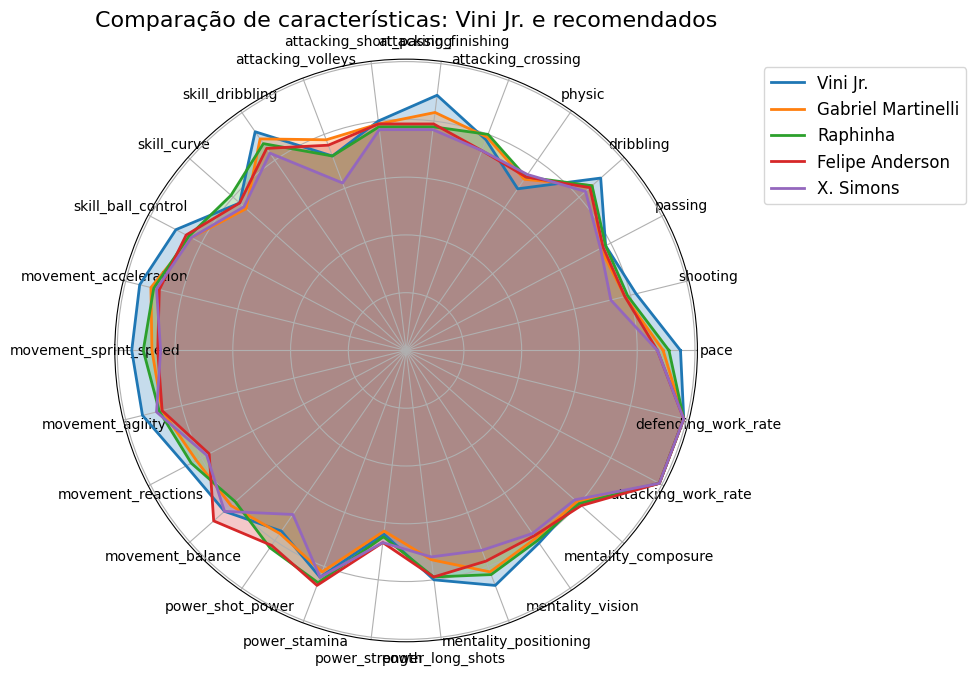

In [40]:
jogador_ref = df_filtrado[df_filtrado['player_id'] == id_jogador_ref]['short_name'].values[0]


top_4 = resultados.head(4)

# Adicionar o jogador de referência ao DataFrame para o gráfico
jogadores_para_grafico = pd.concat([df_filtrado[df_filtrado['player_id'] == id_jogador_ref], df_filtrado[df_filtrado['player_id'].isin(top_4['Player_ID'])]])

# Gráfico de radar
num_features = len(features)
angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
angles += angles[:1]  # Fechar o círculo (adicionando o primeiro valor de volta ao final)

# Criar o gráfico
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Plotar cada jogador no gráfico de radar
for _, jogador in jogadores_para_grafico.iterrows():
    valores = jogador[features].values.tolist()
    valores += valores[:1]  # Fechar o círculo
    ax.plot(angles, valores, linewidth=2, label=jogador['short_name'])
    ax.fill(angles, valores, alpha=0.25)

# Ajustes do gráfico
ax.set_xticks(angles[:-1])  # Evitar a última repetição do ângulo
ax.set_xticklabels(features, fontsize=10, rotation=45)  # Ajustar a fonte
ax.set_yticklabels([])  # Remover os rótulos do eixo Y

# Legenda e título
ax.legend(loc='upper left', bbox_to_anchor=(1.1, 1), fontsize=12)
plt.title(f'Comparação de características: {jogador_ref} e recomendados', fontsize=16)

# Exibir o gráfico
plt.tight_layout()
plt.show()

In [41]:
nome_arquivo_recomendacoes = f"recomendacoes\\top100_recomendacoes_{jogador_ref}_{id_jogador_ref}.csv"

# Verifica se a pasta 'recomendacoes' existe, caso contrário, cria a pasta
pasta_recomendacoes = os.path.dirname(nome_arquivo_recomendacoes)
if not os.path.exists(pasta_recomendacoes):
    os.makedirs(pasta_recomendacoes)
    print(f"Pasta criada: {pasta_recomendacoes}")

# Salva o DataFrame no arquivo CSV
top_100.to_csv(nome_arquivo_recomendacoes, index=False)

print(f"Arquivo salvo: {nome_arquivo_recomendacoes}")

Arquivo salvo: recomendacoes\top100_recomendacoes_Vini Jr._238794.csv
